<a href="https://colab.research.google.com/github/SobiaNoorAI/Deepfake-Detection-Frequency-Domain/blob/main/01_Data_Preparation_and_DCT_Extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Preparation and DCT Extraction

In [3]:
# Install required libraries
!pip install kagglehub opencv-python-headless scipy scikit-image -q

print("✅ All libraries installed successfully!")

✅ All libraries installed successfully!


In [4]:
import kagglehub
import os
import shutil

print("📥 Downloading dataset from Kaggle...")
print("This will take 5-10 minutes...")

# Download using kagglehub (no credentials needed)
path = kagglehub.dataset_download("xhlulu/140k-real-and-fake-faces")

print(f"✅ Dataset downloaded to: {path}")

# Copy to a more convenient location
destination = '/content/real_and_fake_faces'
if os.path.exists(destination):
    shutil.rmtree(destination)
shutil.copytree(path, destination)

print(f"✅ Dataset copied to: {destination}")

📥 Downloading dataset from Kaggle...
This will take 5-10 minutes...


100%|██████████| 3.75G/3.75G [02:39<00:00, 25.3MB/s]

Extracting files...


✅ Dataset downloaded to: /root/.cache/kagglehub/datasets/xhlulu/140k-real-and-fake-faces/versions/2
✅ Dataset copied to: /content/real_and_fake_faces


# Verify Dataset Structure

In [5]:
import os

dataset_path = '/content/real_and_fake_faces'

print("=" * 60)
print("🔍 VERIFYING DATASET STRUCTURE")
print("=" * 60)

if os.path.exists(dataset_path):
    print(f"✅ Dataset path exists: {dataset_path}")

    # Count all files
    total_files = 0
    image_files = []

    for root, dirs, files in os.walk(dataset_path):
        total_files += len(files)
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_files.append(os.path.join(root, file))

    print(f"\n📊 Dataset Statistics:")
    print(f"   Total files: {total_files}")
    print(f"   Image files: {len(image_files)}")

    # Show folder structure (first 2 levels)
    print(f"\n📁 Folder Structure:")
    for root, dirs, files in os.walk(dataset_path):
        level = root.replace(dataset_path, '').count(os.sep)
        indent = ' ' * 2 * level

        # Show up to 2 levels deep
        if level <= 2:
            folder_name = os.path.basename(root)
            if folder_name:
                img_count = sum(1 for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg')))
                print(f'{indent}📁 {folder_name}/ - {img_count} images')
            else:
                print(f'{indent}📁 {dataset_path}/')

            # Show subdirectories
            if level < 2:
                for d in sorted(dirs)[:5]:
                    sub_indent = ' ' * 2 * (level + 1)
                    # Count images in subdirectory
                    sub_path = os.path.join(root, d)
                    sub_img_count = 0
                    for sub_root, sub_dirs, sub_files in os.walk(sub_path):
                        sub_img_count += sum(1 for f in sub_files if f.lower().endswith(('.png', '.jpg', '.jpeg')))
                    print(f'{sub_indent}📁 {d}/ - {sub_img_count} images')

    # Show sample images
    if image_files:
        print(f"\n🖼️ Sample Images (first 5):")
        for i, img_path in enumerate(image_files[:5]):
            rel_path = os.path.relpath(img_path, dataset_path)
            # Determine if real or fake from path
            if 'real' in rel_path.lower():
                label = "REAL"
            elif 'fake' in rel_path.lower():
                label = "FAKE"
            else:
                label = "UNKNOWN"
            print(f"   {i+1}. {rel_path} → {label}")
    else:
        print("\n❌ No images found in the dataset!")
else:
    print(f"❌ Dataset path not found: {dataset_path}")

🔍 VERIFYING DATASET STRUCTURE
✅ Dataset path exists: /content/real_and_fake_faces

📊 Dataset Statistics:
   Total files: 140003
   Image files: 140000

📁 Folder Structure:
📁 real_and_fake_faces/ - 0 images
  📁 real_vs_fake/ - 140000 images
  📁 real_vs_fake/ - 0 images
    📁 real-vs-fake/ - 140000 images
    📁 real-vs-fake/ - 0 images

🖼️ Sample Images (first 5):
   1. real_vs_fake/real-vs-fake/valid/fake/J9FI0FC8GU.jpg → REAL
   2. real_vs_fake/real-vs-fake/valid/fake/OYWV1KIWAU.jpg → REAL
   3. real_vs_fake/real-vs-fake/valid/fake/2TBD7SAVY0.jpg → REAL
   4. real_vs_fake/real-vs-fake/valid/fake/EIF8C87GTJ.jpg → REAL
   5. real_vs_fake/real-vs-fake/valid/fake/VSFXTVCL3G.jpg → REAL


# Install DCT Libraries

In [6]:
# Install scientific computing libraries
!pip install scipy opencv-python-headless -q

import numpy as np
import cv2
from scipy.fftpack import dct
import os
from PIL import Image
import matplotlib.pyplot as plt

print("✅ All libraries installed and imported!")
print(f"   NumPy version: {np.__version__}")
print(f"   OpenCV version: {cv2.__version__}")

✅ All libraries installed and imported!
   NumPy version: 2.0.2
   OpenCV version: 4.13.0


🔬 DCT FREQUENCY ANALYSIS

🟢 REAL Image: J9FI0FC8GU.jpg


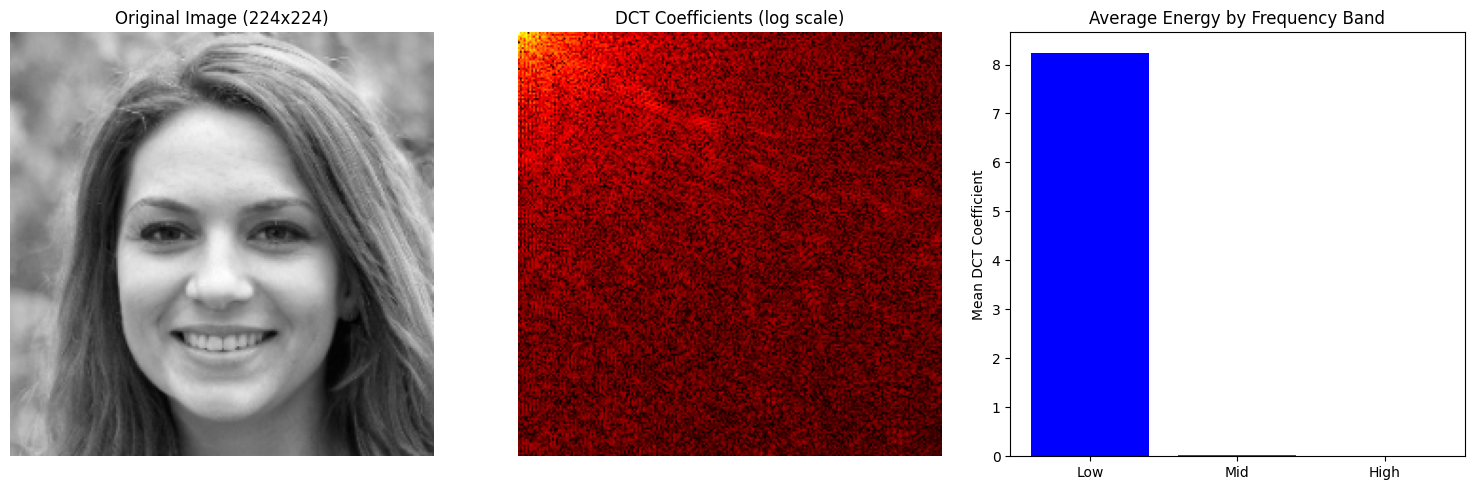

📊 Frequency Band Analysis:
   Low frequency mean: 8.2452
   Mid frequency mean: 0.0239
   High frequency mean: 0.0040

🔴 FAKE Image: OYWV1KIWAU.jpg


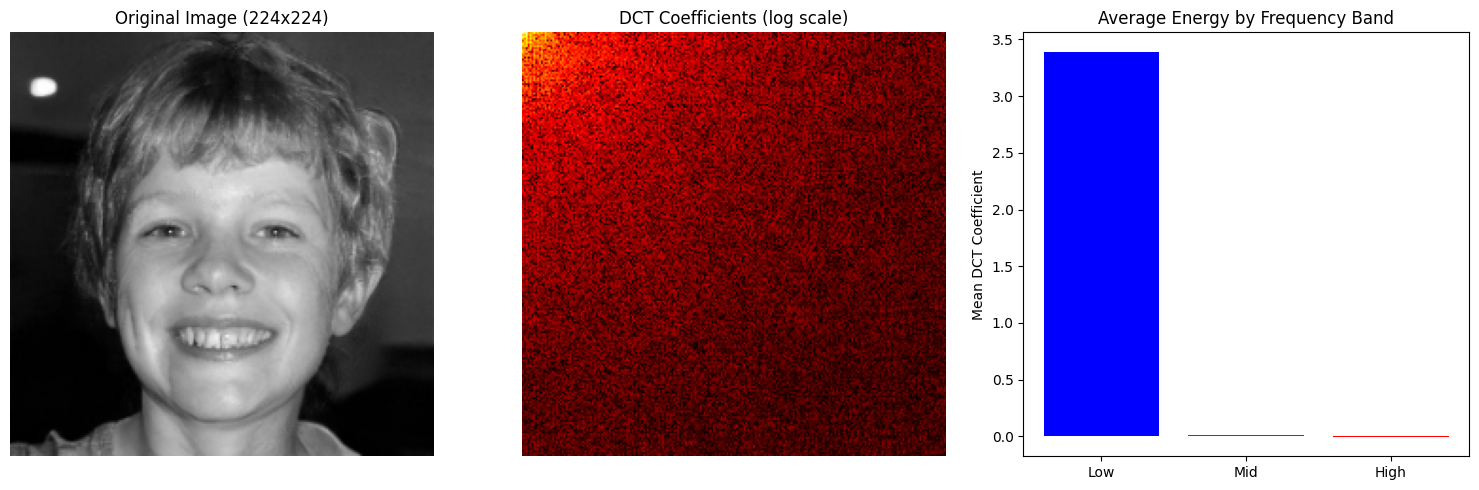

📊 Frequency Band Analysis:
   Low frequency mean: 3.3926
   Mid frequency mean: 0.0080
   High frequency mean: -0.0055


In [7]:
import numpy as np
import cv2
from scipy.fftpack import dct
import matplotlib.pyplot as plt
import os

def visualize_dct(image_path):
    """Visualize original image and its DCT frequency components"""

    # Load image
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("❌ Failed to load image")
        return

    # Resize for consistency
    img_resized = cv2.resize(img, (224, 224))

    # Apply DCT
    dct_coeffs = dct(dct(img_resized.T, norm='ortho').T, norm='ortho')

    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original image
    axes[0].imshow(img_resized, cmap='gray')
    axes[0].set_title('Original Image (224x224)')
    axes[0].axis('off')

    # DCT coefficients (log scale for visibility)
    dct_log = np.log(np.abs(dct_coeffs) + 1)
    axes[1].imshow(dct_log, cmap='hot')
    axes[1].set_title('DCT Coefficients (log scale)')
    axes[1].axis('off')

    # Frequency band separation
    h, w = dct_coeffs.shape
    # Low frequency
    low_freq = dct_coeffs[:h//4, :w//4]
    # High frequency
    high_freq = dct_coeffs[h//2:, w//2:]

    # Show frequency distribution
    bands = ['Low', 'Mid', 'High']
    means = [
        np.mean(dct_coeffs[:h//4, :w//4]),
        np.mean(dct_coeffs[h//4:h//2, w//4:w//2]),
        np.mean(dct_coeffs[h//2:, w//2:])
    ]

    axes[2].bar(bands, means, color=['blue', 'green', 'red'])
    axes[2].set_title('Average Energy by Frequency Band')
    axes[2].set_ylabel('Mean DCT Coefficient')

    plt.tight_layout()
    plt.show()

    # Print statistics
    print(f"📊 Frequency Band Analysis:")
    print(f"   Low frequency mean: {means[0]:.4f}")
    print(f"   Mid frequency mean: {means[1]:.4f}")
    print(f"   High frequency mean: {means[2]:.4f}")

    return dct_coeffs

# Find sample images (one real, one fake)
dataset_path = '/content/real_and_fake_faces'
real_image = None
fake_image = None

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            file_path = os.path.join(root, file)
            if 'real' in file_path.lower() and real_image is None:
                real_image = file_path
            elif 'fake' in file_path.lower() and fake_image is None:
                fake_image = file_path
            if real_image and fake_image:
                break
    if real_image and fake_image:
        break

print("=" * 60)
print("🔬 DCT FREQUENCY ANALYSIS")
print("=" * 60)

if real_image:
    print(f"\n🟢 REAL Image: {os.path.basename(real_image)}")
    visualize_dct(real_image)
else:
    print("❌ No REAL image found")

if fake_image:
    print(f"\n🔴 FAKE Image: {os.path.basename(fake_image)}")
    visualize_dct(fake_image)
else:
    print("❌ No FAKE image found")

# Visualize DCT Frequency Analysis

In [8]:
import numpy as np
import cv2
from scipy.fftpack import dct
import os

def extract_dct_features(image_path, img_size=224):
    """
    Extract DCT frequency domain features from an image.
    Returns: 9 features (mean, std, IQR for low, mid, high frequency bands)
    """
    # Load image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"❌ Failed to load image: {image_path}")
        return None

    # Resize
    img = cv2.resize(img, (img_size, img_size))

    # Apply 2D DCT
    dct_coeffs = dct(dct(img.T, norm='ortho').T, norm='ortho')

    # Extract features from frequency bands
    h, w = dct_coeffs.shape
    bands = {
        'low': dct_coeffs[:h//4, :w//4],
        'mid': dct_coeffs[h//4:h//2, w//4:w//2],
        'high': dct_coeffs[h//2:, w//2:]
    }

    features = []
    feature_names = []

    for band_name, band in bands.items():
        if band.size > 0:
            # Mean, standard deviation, and Interquartile Range (IQR)
            features.extend([
                np.mean(band),
                np.std(band),
                np.percentile(band, 75) - np.percentile(band, 25)
            ])
            feature_names.extend([
                f'{band_name}_mean',
                f'{band_name}_std',
                f'{band_name}_iqr'
            ])

    return np.array(features), feature_names

# Test the function on a sample image
print("=" * 60)
print("🧪 TESTING DCT FEATURE EXTRACTOR")
print("=" * 60)

# Find any image to test
test_image = None
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            test_image = os.path.join(root, file)
            break
    if test_image:
        break

if test_image:
    print(f"\n📸 Testing on: {os.path.basename(test_image)}")
    features, feature_names = extract_dct_features(test_image)

    if features is not None:
        print(f"\n✅ DCT Features Extracted: {len(features)} features")
        print("\n📊 Feature Values:")
        for name, value in zip(feature_names, features):
            print(f"   {name}: {value:.4f}")
    else:
        print("❌ Feature extraction failed")
else:
    print("❌ No test image found")

🧪 TESTING DCT FEATURE EXTRACTOR

📸 Testing on: J9FI0FC8GU.jpg

✅ DCT Features Extracted: 9 features

📊 Feature Values:
   low_mean: 8.2452
   low_std: 520.6765
   low_iqr: 56.3434
   mid_mean: 0.0239
   mid_std: 8.5523
   mid_iqr: 10.5445
   high_mean: 0.0040
   high_std: 3.7747
   high_iqr: 4.8922


# DCT Feature Extractor Function

In [9]:
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import numpy as np
import cv2
from scipy.fftpack import dct
import os

class DeepfakeFrequencyDataset(Dataset):
    """
    Dataset that returns BOTH RGB image AND DCT frequency features
    for dual-branch deepfake detection
    """

    def __init__(self, root_dir, transform=None, img_size=224):
        self.root_dir = root_dir
        self.transform = transform
        self.img_size = img_size
        self.image_paths = []
        self.labels = []

        print(f"\n🔍 Building dataset from: {root_dir}")

        # Walk through all directories
        for root, dirs, files in os.walk(root_dir):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    file_path = os.path.join(root, file)

                    # Determine label from folder names
                    path_parts = root.split(os.sep)
                    label = -1

                    for part in path_parts:
                        if 'real' in part.lower():
                            label = 0  # Real
                            break
                        elif 'fake' in part.lower():
                            label = 1  # Fake
                            break

                    if label != -1:
                        self.image_paths.append(file_path)
                        self.labels.append(label)

        print(f"✅ Loaded {len(self.image_paths)} images")
        if len(self.image_paths) > 0:
            real_count = sum(1 for l in self.labels if l == 0)
            fake_count = sum(1 for l in self.labels if l == 1)
            print(f"   🟢 Real: {real_count}")
            print(f"   🔴 Fake: {fake_count}")

            # Show sample paths
            print(f"\n📸 Sample images:")
            for i in range(min(3, len(self.image_paths))):
                rel_path = os.path.relpath(self.image_paths[i], root_dir)
                label_name = "REAL" if self.labels[i] == 0 else "FAKE"
                print(f"   {i+1}. {rel_path} → {label_name}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        # ----- SPATIAL BRANCH: RGB Image -----
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            rgb_image = self.transform(image)

        # ----- FREQUENCY BRANCH: DCT Features -----
        dct_features, _ = extract_dct_features(img_path, self.img_size)
        if dct_features is None:
            dct_features = np.zeros(9)  # Fallback
        dct_tensor = torch.tensor(dct_features, dtype=torch.float32)

        return rgb_image, dct_tensor, label

# Test the dataset
print("\n" + "=" * 60)
print("🚀 TESTING PYTORCH DATASET")
print("=" * 60)

# Create transform for RGB images
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create dataset
dataset = DeepfakeFrequencyDataset(dataset_path, transform=transform)

if len(dataset) > 0:
    # Test loading a sample
    print(f"\n🧪 Testing sample loading...")
    rgb, dct, label = dataset[0]
    print(f"   ✅ Sample loaded successfully!")
    print(f"   RGB shape: {rgb.shape}")
    print(f"   DCT features shape: {dct.shape}")
    print(f"   DCT features (first 5): {dct[:5].tolist()}")
    label_name = "REAL" if label == 0 else "FAKE"
    print(f"   Label: {label} ({label_name})")
else:
    print("❌ No samples loaded! Check dataset structure.")


🚀 TESTING PYTORCH DATASET

🔍 Building dataset from: /content/real_and_fake_faces
✅ Loaded 140000 images
   🟢 Real: 140000
   🔴 Fake: 0

📸 Sample images:
   1. real_vs_fake/real-vs-fake/valid/fake/J9FI0FC8GU.jpg → REAL
   2. real_vs_fake/real-vs-fake/valid/fake/OYWV1KIWAU.jpg → REAL
   3. real_vs_fake/real-vs-fake/valid/fake/2TBD7SAVY0.jpg → REAL

🧪 Testing sample loading...
   ✅ Sample loaded successfully!
   RGB shape: torch.Size([3, 224, 224])
   DCT features shape: torch.Size([9])
   DCT features (first 5): [8.245176315307617, 520.6764526367188, 56.34335708618164, 0.02393420599400997, 8.55228328704834]
   Label: 0 (REAL)


# Dataset Class with Correct Label Detection

In [11]:
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import numpy as np
import cv2
from scipy.fftpack import dct as scipy_dct  # Rename to avoid conflict
import os

def extract_dct_features_fixed(image_path, img_size=224):
    """Extract DCT frequency features from an image - FIXED version"""
    # Load image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    # Resize
    img = cv2.resize(img, (img_size, img_size))

    # Apply 2D DCT (using renamed import)
    dct_coeffs = scipy_dct(scipy_dct(img.T, norm='ortho').T, norm='ortho')

    # Extract features from frequency bands
    h, w = dct_coeffs.shape
    bands = {
        'low': dct_coeffs[:h//4, :w//4],
        'mid': dct_coeffs[h//4:h//2, w//4:w//2],
        'high': dct_coeffs[h//2:, w//2:]
    }

    features = []
    for band in bands.values():
        if band.size > 0:
            features.extend([
                np.mean(band),
                np.std(band),
                np.percentile(band, 75) - np.percentile(band, 25)
            ])

    return np.array(features)

class FinalDeepfakeDataset(Dataset):
    """Final dataset with fixed DCT extraction"""

    def __init__(self, root_dir, transform=None, img_size=224, limit=None):
        self.root_dir = root_dir
        self.transform = transform
        self.img_size = img_size
        self.image_paths = []
        self.labels = []

        print(f"\n🔍 Building dataset from: {root_dir}")

        # Walk through all directories
        for root, dirs, files in os.walk(root_dir):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    file_path = os.path.join(root, file)

                    # Get the immediate parent folder name
                    parent_folder = os.path.basename(root).lower()

                    # Determine label from parent folder name
                    if parent_folder == 'real':
                        label = 0  # Real
                    elif parent_folder == 'fake':
                        label = 1  # Fake
                    else:
                        # If parent is not 'real' or 'fake', check grandparent
                        grandparent = os.path.basename(os.path.dirname(root)).lower()
                        if grandparent == 'real':
                            label = 0
                        elif grandparent == 'fake':
                            label = 1
                        else:
                            continue

                    self.image_paths.append(file_path)
                    self.labels.append(label)

        # Optionally limit dataset size for faster testing
        if limit and len(self.image_paths) > limit:
            import random
            indices = random.sample(range(len(self.image_paths)), limit)
            self.image_paths = [self.image_paths[i] for i in indices]
            self.labels = [self.labels[i] for i in indices]

        print(f"✅ Loaded {len(self.image_paths)} images")
        if len(self.image_paths) > 0:
            real_count = sum(1 for l in self.labels if l == 0)
            fake_count = sum(1 for l in self.labels if l == 1)
            print(f"   🟢 Real: {real_count}")
            print(f"   🔴 Fake: {fake_count}")

            # Show sample paths with correct labels
            print(f"\n📸 Sample images:")
            for i in range(min(5, len(self.image_paths))):
                rel_path = os.path.relpath(self.image_paths[i], root_dir)
                label_name = "REAL" if self.labels[i] == 0 else "FAKE"
                print(f"   {i+1}. {rel_path} → {label_name}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        # Spatial branch: RGB image
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            rgb_image = self.transform(image)

        # Frequency branch: DCT features (using fixed function)
        dct_features = extract_dct_features_fixed(img_path, self.img_size)
        if dct_features is None:
            dct_features = np.zeros(9)

        dct_tensor = torch.tensor(dct_features, dtype=torch.float32)

        return rgb_image, dct_tensor, label

# Test the final dataset
print("\n" + "=" * 60)
print("🚀 TESTING FINAL DATASET (FIXED)")
print("=" * 60)

dataset_path = '/content/real_and_fake_faces'

if os.path.exists(dataset_path):
    # Create transform
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Create dataset with limit for faster testing (use 1000 samples for now)
    dataset = FinalDeepfakeDataset(dataset_path, transform=transform, limit=2000)

    if len(dataset) > 0:
        # Test loading samples
        print(f"\n🧪 Testing sample loading...")

        # Load first sample
        rgb, dct, label = dataset[0]
        label_name = "REAL" if label == 0 else "FAKE"
        print(f"   Sample 1: Label={label} ({label_name})")
        print(f"   RGB shape: {rgb.shape}")
        print(f"   DCT features shape: {dct.shape}")
        print(f"   DCT features (first 5): {dct[:5].tolist()}")

        # Check if we have both real and fake samples
        real_samples = [i for i in range(len(dataset)) if dataset.labels[i] == 0]
        fake_samples = [i for i in range(len(dataset)) if dataset.labels[i] == 1]

        print(f"\n📊 Dataset Summary:")
        print(f"   Total samples: {len(dataset)}")
        print(f"   Real samples: {len(real_samples)}")
        print(f"   Fake samples: {len(fake_samples)}")

        if len(real_samples) > 0 and len(fake_samples) > 0:
            print(f"\n✅ Both REAL and FAKE samples found!")

            # Show one real and one fake sample
            real_idx = real_samples[0]
            fake_idx = fake_samples[0]

            print(f"\n🟢 REAL sample: {os.path.basename(dataset.image_paths[real_idx])}")
            real_rgb, real_dct, real_label = dataset[real_idx]
            print(f"   DCT features (first 3): {real_dct[:3].tolist()}")

            print(f"\n🔴 FAKE sample: {os.path.basename(dataset.image_paths[fake_idx])}")
            fake_rgb, fake_dct, fake_label = dataset[fake_idx]
            print(f"   DCT features (first 3): {fake_dct[:3].tolist()}")

            # Compare the frequency patterns
            print(f"\n📊 Frequency Pattern Comparison:")
            print(f"   REAL low_freq_mean: {real_dct[0]:.4f}")
            print(f"   FAKE low_freq_mean: {fake_dct[0]:.4f}")
            print(f"   REAL mid_freq_mean: {real_dct[3]:.4f}")
            print(f"   FAKE mid_freq_mean: {fake_dct[3]:.4f}")

        else:
            print(f"\n⚠️ Only one class found! Check dataset structure.")
    else:
        print("❌ No samples loaded!")
else:
    print(f"❌ Dataset path not found: {dataset_path}")

print("\n" + "=" * 60)
print("✅ DATASET READY FOR DUAL-BRANCH MODEL!")
print("=" * 60)


🚀 TESTING FINAL DATASET (FIXED)

🔍 Building dataset from: /content/real_and_fake_faces
✅ Loaded 2000 images
   🟢 Real: 1041
   🔴 Fake: 959

📸 Sample images:
   1. real_vs_fake/real-vs-fake/train/real/21173.jpg → REAL
   2. real_vs_fake/real-vs-fake/train/real/18687.jpg → REAL
   3. real_vs_fake/real-vs-fake/train/real/46055.jpg → REAL
   4. real_vs_fake/real-vs-fake/train/real/56346.jpg → REAL
   5. real_vs_fake/real-vs-fake/train/fake/5JNUOF3WRZ.jpg → FAKE

🧪 Testing sample loading...
   Sample 1: Label=0 (REAL)
   RGB shape: torch.Size([3, 224, 224])
   DCT features shape: torch.Size([9])
   DCT features (first 5): [11.703125953674316, 545.5880737304688, 75.70809936523438, -0.7235223650932312, 15.767845153808594]

📊 Dataset Summary:
   Total samples: 2000
   Real samples: 1041
   Fake samples: 959

✅ Both REAL and FAKE samples found!

🟢 REAL sample: 21173.jpg
   DCT features (first 3): [11.703125953674316, 545.5880737304688, 75.70809936523438]

🔴 FAKE sample: 5JNUOF3WRZ.jpg
   DCT f